In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 기본 테마 설정
sns.set_theme(palette="coolwarm", style="darkgrid", font_scale=1)

# 그래프를 그리기 위한 기본 설정
plt.rcParams['font.family'] = 'NanumSquare_ac'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

In [2]:
bank_df = pd.read_csv('data/bank.csv')
bank_df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


# 전체 칼럼 체크
age : 고객 나이 (이상치 존재)

job : 고객의 직업 **(admin/technician/services/management/retired/
blue-collar/unemployed/entrepreneur/housemaid/
unknown/self-employed/student)**

martial : 결혼유무 **(married/single/divorced)**

education : 학력 **(primary/secondary/tertiary/unknown)**

default : 신용불이행(불량자) 여부 **(yes/no)**

balance : 고객의 연평균 잔고 (이상치 존재)

housing : 기존 주택담보대출 보유 여부 **(yes/no)**

loan : 기존 대출 보유 여부 **(yes/no)**

↘ 이번 캠페인 외 개인이 기존 대출 보유하고 있었는지?

contact : (은행측에서) 컨택 채널 **(cellular, telephone, unknown)**

day : (은행측에서) 연락한 날짜 (이상치 없음, 1~31)

month : (은행측에서) 연락한 월 (jan ~ dec)

duration : (은행측에서 접촉 후) 통화 시간 (이상치 존재)

campaign : 이번 캠페인에서 고객에 컨택한 횟수? (이상치 존재)

pdays : 과거 캠페인 이후 지난 일수 (이상치 존재)

↘ -1인 경우 과거 접촉 없음 = 이번 캠페인 신규 접촉 의미

previous :  과거 캠페인 접촉 횟수 (이상치 존재) 

poutcome : 과거 캠페인 결과 **(success / failure / unknown / other)**

🎯 **deposit : 예금 상품 가입 여부 (YES/NO)**

# 이상치 있나요? 

제 1사분위수: 32.0 | 중앙값: 39.0 | 제 3사분위수: 49.0 | IQR: 17.0
안울타리 범위: 6.5 ~ 74.5


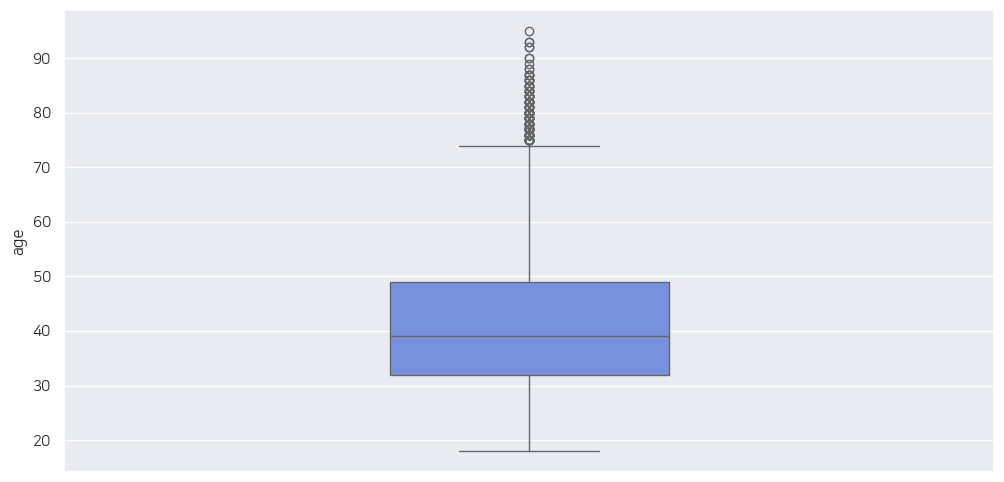

In [3]:
Q1 = bank_df['age'].quantile(0.25)
Q2 = bank_df['age'].median()
Q3 = bank_df['age'].quantile(0.75)
IQR = Q3-Q1

print(f'제 1사분위수: {Q1} | 중앙값: {Q2} | 제 3사분위수: {Q3} | IQR: {IQR}')
print(f'안울타리 범위: {Q1 - (1.5 * IQR)} ~ {Q3 + (1.5 * IQR)}')

sns.boxplot(bank_df['age'], width = 0.3)
plt.show()

제 1사분위수: 122.0 | 중앙값: 550.0 | 제 3사분위수: 1708.0 | IQR: 1586.0
안울타리 범위: -2257.0 ~ 4087.0


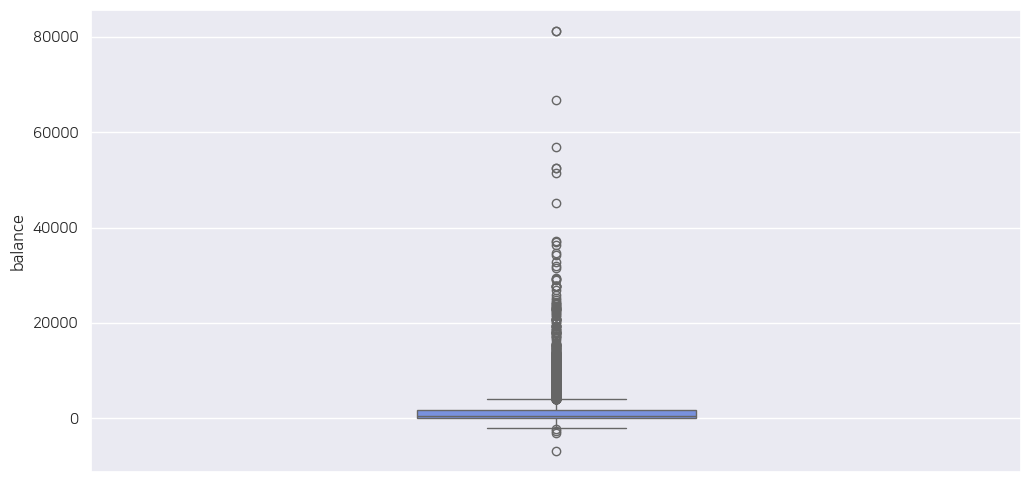

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
5,42,management,single,tertiary,no,0,yes,yes,unknown,5,may,562,2,-1,0,unknown,yes
8,37,technician,married,secondary,no,1,yes,no,unknown,6,may,608,1,-1,0,unknown,yes
10,38,admin.,single,secondary,no,100,yes,no,unknown,7,may,786,1,-1,0,unknown,yes
17,49,services,married,secondary,no,-8,yes,no,unknown,8,may,1119,1,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11156,34,blue-collar,single,secondary,no,-72,yes,no,cellular,7,jul,273,5,-1,0,unknown,no
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [4]:
Q1 = bank_df['balance'].quantile(0.25)
Q2 = bank_df['balance'].median()
Q3 = bank_df['balance'].quantile(0.75)
IQR = Q3-Q1

print(f'제 1사분위수: {Q1} | 중앙값: {Q2} | 제 3사분위수: {Q3} | IQR: {IQR}')
print(f'안울타리 범위: {Q1 - (1.5 * IQR)} ~ {Q3 + (1.5 * IQR)}')

sns.boxplot(bank_df['balance'], width = 0.3)
plt.show()
# 이거 뭔데 음수 이상치가 있어? 

bank_df.query('balance < @Q1')

제 1사분위수: 8.0 | 중앙값: 15.0 | 제 3사분위수: 22.0 | IQR: 14.0
안울타리 범위: -13.0 ~ 43.0


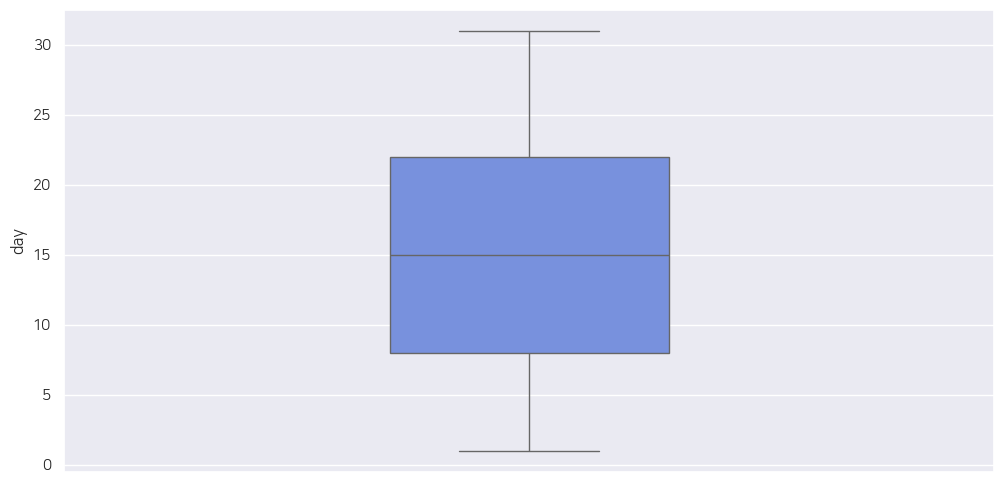

In [5]:
Q1 = bank_df['day'].quantile(0.25)
Q2 = bank_df['day'].median()
Q3 = bank_df['day'].quantile(0.75)
IQR = Q3-Q1

print(f'제 1사분위수: {Q1} | 중앙값: {Q2} | 제 3사분위수: {Q3} | IQR: {IQR}')
print(f'안울타리 범위: {Q1 - (1.5 * IQR)} ~ {Q3 + (1.5 * IQR)}')

sns.boxplot(bank_df['day'], width = 0.3)
plt.show()
# 이상치 X

제 1사분위수: 138.0 | 중앙값: 255.0 | 제 3사분위수: 496.0 | IQR: 358.0
안울타리 범위: -399.0 ~ 1033.0


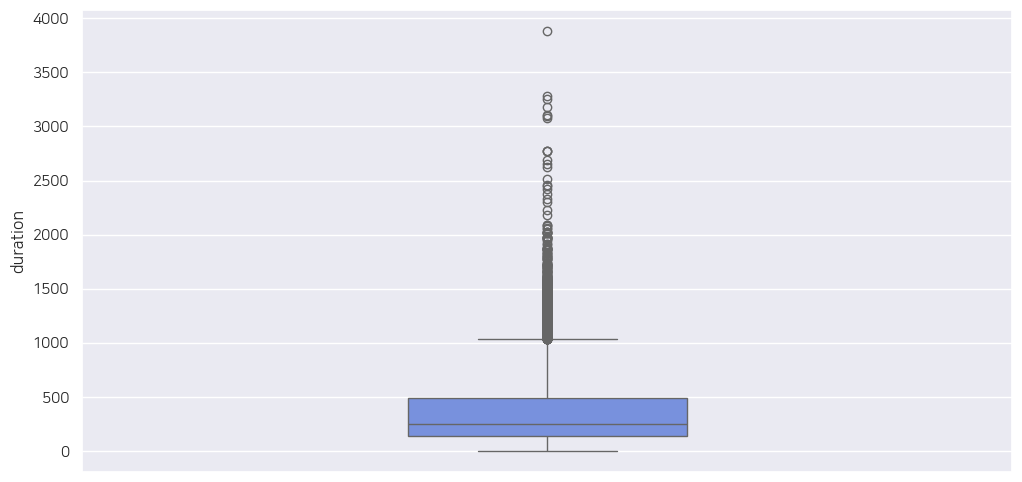

In [6]:
Q1 = bank_df['duration'].quantile(0.25)
Q2 = bank_df['duration'].median()
Q3 = bank_df['duration'].quantile(0.75)
IQR = Q3-Q1

print(f'제 1사분위수: {Q1} | 중앙값: {Q2} | 제 3사분위수: {Q3} | IQR: {IQR}')
print(f'안울타리 범위: {Q1 - (1.5 * IQR)} ~ {Q3 + (1.5 * IQR)}')

sns.boxplot(bank_df['duration'], width = 0.3)
plt.show()

제 1사분위수: 1.0 | 중앙값: 2.0 | 제 3사분위수: 3.0 | IQR: 2.0
안울타리 범위: -2.0 ~ 6.0


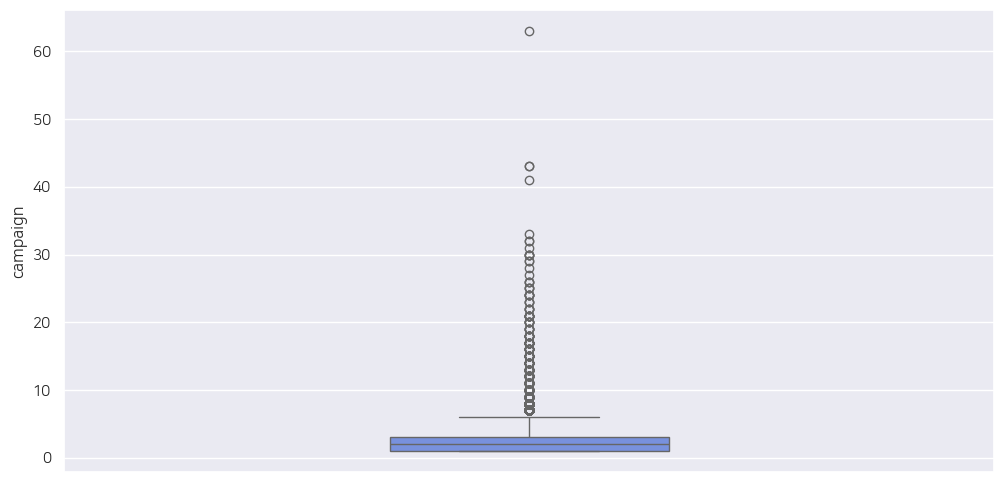

In [7]:
Q1 = bank_df['campaign'].quantile(0.25)
Q2 = bank_df['campaign'].median()
Q3 = bank_df['campaign'].quantile(0.75)
IQR = Q3-Q1

print(f'제 1사분위수: {Q1} | 중앙값: {Q2} | 제 3사분위수: {Q3} | IQR: {IQR}')
print(f'안울타리 범위: {Q1 - (1.5 * IQR)} ~ {Q3 + (1.5 * IQR)}')

sns.boxplot(bank_df['campaign'], width = 0.3)
plt.show()

제 1사분위수: -1.0 | 중앙값: -1.0 | 제 3사분위수: 20.75 | IQR: 21.75
안울타리 범위: -33.625 ~ 53.375


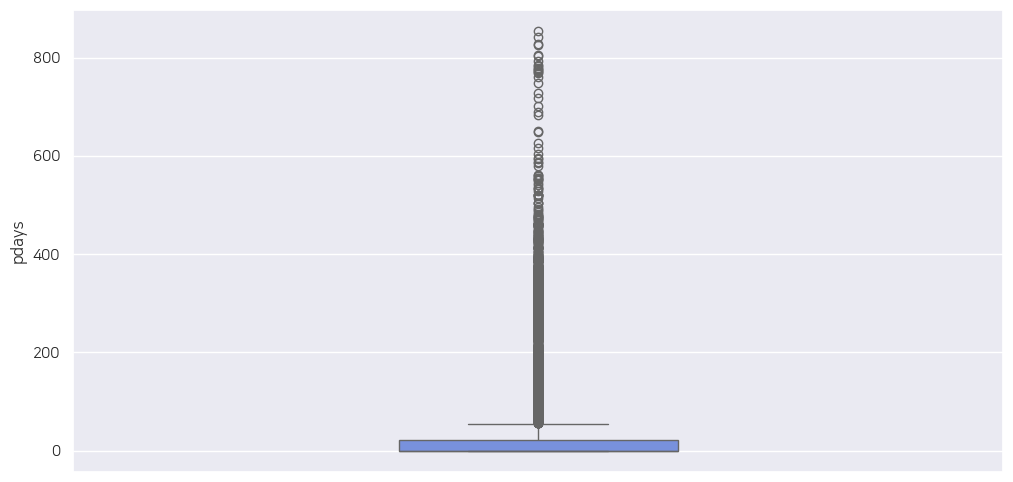

In [8]:
Q1 = bank_df['pdays'].quantile(0.25)
Q2 = bank_df['pdays'].median()
Q3 = bank_df['pdays'].quantile(0.75)
IQR = Q3-Q1

print(f'제 1사분위수: {Q1} | 중앙값: {Q2} | 제 3사분위수: {Q3} | IQR: {IQR}')
print(f'안울타리 범위: {Q1 - (1.5 * IQR)} ~ {Q3 + (1.5 * IQR)}')

sns.boxplot(bank_df['pdays'], width = 0.3)
plt.show()

제 1사분위수: 0.0 | 중앙값: 0.0 | 제 3사분위수: 1.0 | IQR: 1.0
안울타리 범위: -1.5 ~ 2.5


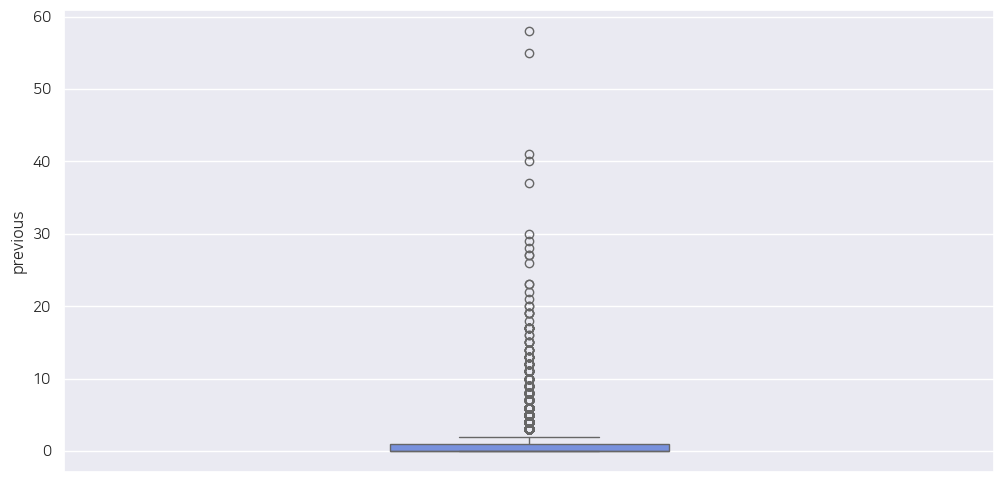

In [9]:
Q1 = bank_df['previous'].quantile(0.25)
Q2 = bank_df['previous'].median()
Q3 = bank_df['previous'].quantile(0.75)
IQR = Q3-Q1

print(f'제 1사분위수: {Q1} | 중앙값: {Q2} | 제 3사분위수: {Q3} | IQR: {IQR}')
print(f'안울타리 범위: {Q1 - (1.5 * IQR)} ~ {Q3 + (1.5 * IQR)}')

sns.boxplot(bank_df['previous'], width = 0.3)
plt.show()

## 요약
- day칼럼을 제외하면 전부 이상치가 존재함.

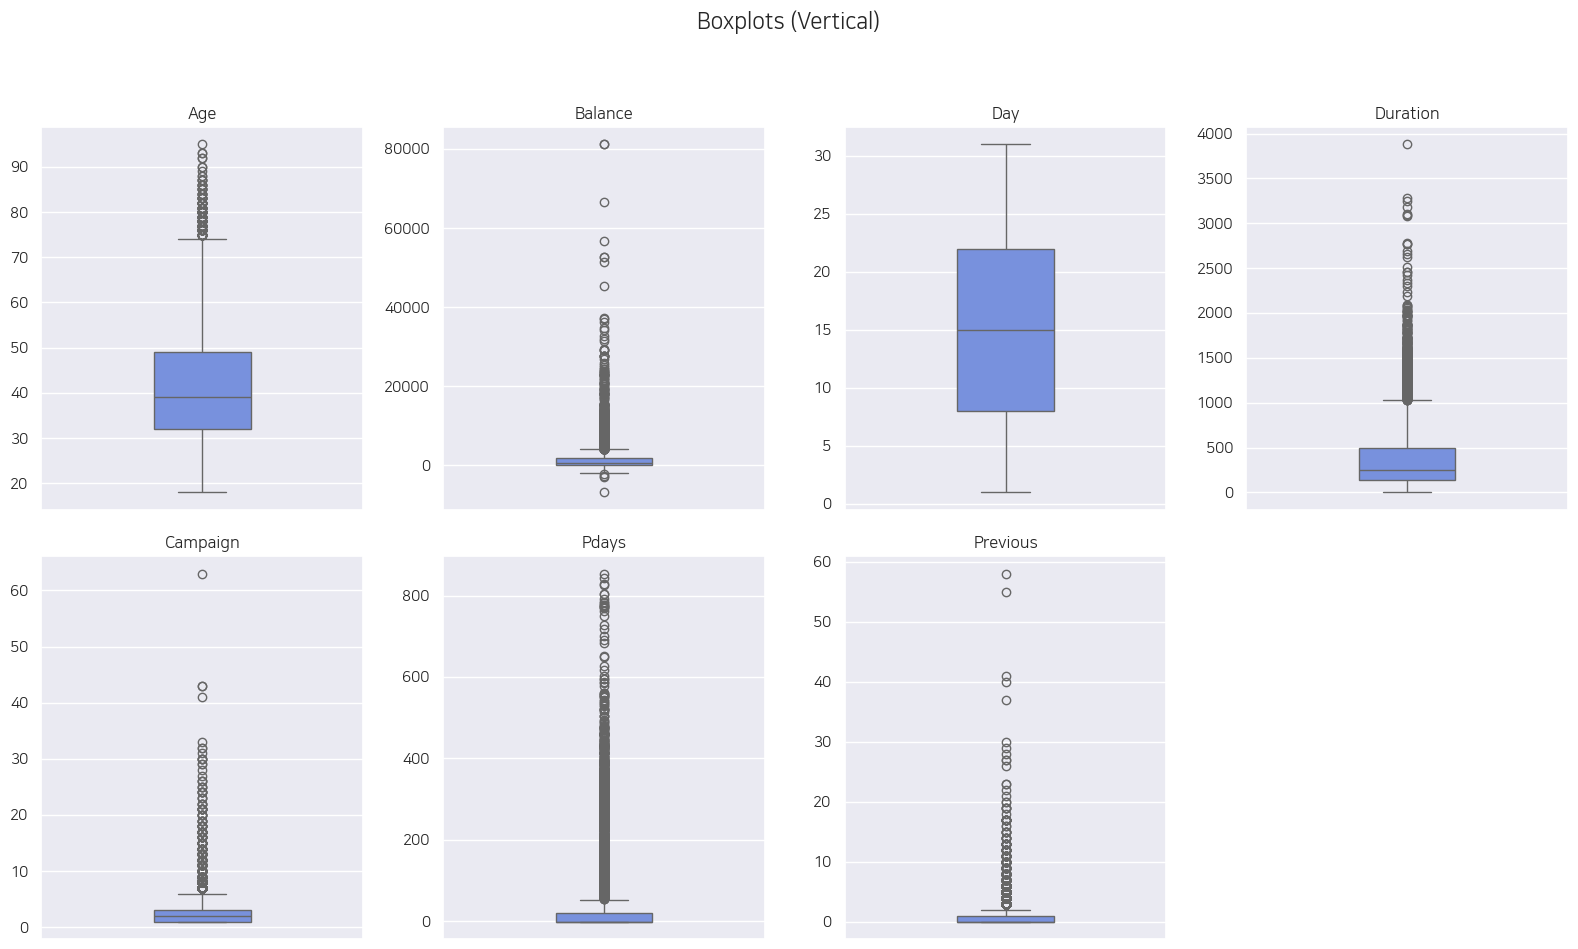

In [10]:
# 분석할 수치형 칼럼 리스트
cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# 2행 4열 설정
fig, ax = plt.subplots(2, 4, figsize=(16, 10))
fig.suptitle('Boxplots (Vertical)', fontsize=16)

# 반복문을 돌면서 그래프 그리기
for i, col in enumerate(cols):
    row = i // 4  # 행 인덱스 (0 또는 1)
    col_idx = i % 4  # 열 인덱스 (0, 1, 2, 3)
    
    # y=bank_df[col] 로 설정하면 상자들이 벌떡 일어납니다!
    sns.boxplot(y=bank_df[col], width=0.3, ax=ax[row][col_idx])
    ax[row][col_idx].set_title(col.capitalize()) # 첫 글자 대문자로 제목 설정
    ax[row][col_idx].set_ylabel('') # y축 라벨 지우기 (제목이랑 중복되니까요)

# 마지막 빈 칸 숨기기
ax[1][3].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 전처리

## 나이 범주화

In [11]:
# 전체 df
bank_df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [12]:
# 이거 그냥 묶으면 안되고 연령대별로 범주화 해야 합니다. 
bank_df['age'].min() # 18
bank_df['age'].max() # 95

# 나이를 10단위로 나눠서 10~19, 20~29 이런 식으로 연령대를 만들겁니다. 
bank_df['age_group'] = 10 # 더미입니다! 값 바꿀거예요!! 

# 그거... 아시나요? 판다스에는... 컷이라는 게 존재합니다. 
bins = list(range(10, 110, 10)) # 10~100까지 틱 10(컷하는 기준)
labels = list(range(10, 100, 10)) # 라벨은 10부터 90까지
bank_df['age_group'] = pd.cut(bank_df['age'], bins = bins, labels = labels, right=False) # 범위랑 라벨 설정해주면 됩니다. 

bank_df[['age','age_group']] # 확인용 코드

,age,age_group
0,59,50
1,56,50
2,41,40
3,55,50
4,54,50
...,...,...
11157,33,30
11158,39,30
11159,32,30
11160,43,40


## Previous 그룹 만들기
- previous가 0이면 new, 0보다 크면 remarketing으로 분류합니다. 

In [13]:
# 일단 칼럼을 만듭니다. 
bank_df['previous_group'] = 'new' # 더미 (값 안채우면 오류나서...)

# 자, 이제 previous가 0보다 큰 사람의 인덱스를 찾아줍니다. 
p_remarketing = bank_df.query('previous > 0').index

# 아... 반복문 아... 
for i in p_remarketing:
    bank_df.loc[i, 'previous_group'] = 'remarketing'

In [14]:
display(bank_df[['previous','previous_group']].query('previous == 0')) # new
display(bank_df[['previous','previous_group']].query('previous > 0')) # remarketing

,previous,previous_group
0,0,new
1,0,new
2,0,new
3,0,new
4,0,new
...,...,...
11156,0,new
11157,0,new
11158,0,new
11159,0,new


,previous,previous_group
890,1,remarketing
891,4,remarketing
899,2,remarketing
933,3,remarketing
951,1,remarketing
...,...,...
11125,3,remarketing
11133,5,remarketing
11145,4,remarketing
11155,2,remarketing


In [15]:
bank_df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,age_group,previous_group
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes,50,new
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes,50,new
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes,40,new
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes,50,new
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes,50,new
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no,30,new
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no,30,new
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no,30,new
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no,40,remarketing


## 잔액으로 그룹 나누기
이름은 좀 직관적으로 했습니다. 
- 잔액이 0보다 작음: minus
- 잔액이 0: zero
- 잔액이 0보다 큼: plus

In [16]:
# 아니 -6847원은 대체 뭐하느라고... 
bank_df['balance'].min() # -6847
bank_df['balance'].max() # 81204

81204

In [17]:
deficit_bal = bank_df.query('balance < 0').index # 마통이신 분 
zero_bal = bank_df.query('balance == 0').index # 0원이... 계셔? (놀랍게도 계심)
profit_bal = bank_df.query('balance > 0').index # 잔고가 양수인 분 

bank_df['balance_group'] = 'minus' # 마통

# 0이신 분
for i in zero_bal:
    bank_df.loc[i, 'balance_group'] = 'zero'

# 양수이신 분
for i in profit_bal:
    bank_df.loc[i, 'balance_group'] = 'plus'

In [18]:
bank_df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,age_group,previous_group,balance_group
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes,50,new,plus
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes,50,new,plus
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes,40,new,plus
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes,50,new,plus
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes,50,new,plus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no,30,new,plus
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no,30,new,plus
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no,30,new,plus
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no,40,remarketing,zero


In [19]:
bank_df[['balance','balance_group']]

,balance,balance_group
0,2343,plus
1,45,plus
2,1270,plus
3,2476,plus
4,184,plus
...,...,...
11157,1,plus
11158,733,plus
11159,29,plus
11160,0,zero


## campaign 칼럼 범주화
- 한 번만 연락한 경우: single_touch
- 두 번 이상 연락한 경우: multi_touch

In [20]:
# 캠페인: '현재' 진행 중인 마케팅 활동
bank_df['campaign_group'] = 'single_touch' # 임시 값

# campaign이 1보다 크면 RT로 바꿀거니까 인덱스를 넘겨라
campaign_re = bank_df.query('campaign > 1').index # 드리겠습니다

for i in campaign_re:
    bank_df.loc[i, 'campaign_group'] = 'multi_touch'

In [21]:
bank_df[['campaign', 'campaign_group']]

,campaign,campaign_group
0,1,single_touch
1,1,single_touch
2,1,single_touch
3,1,single_touch
4,2,multi_touch
...,...,...
11157,1,single_touch
11158,4,multi_touch
11159,2,multi_touch
11160,2,multi_touch


In [22]:
bank_df.query('housing == "yes" and loan == "yes" and default == "yes"')[['balance']]

,balance
216,-754
380,1085
408,327
1555,-443
1847,-106
4597,-274
4659,-405
5354,65
5611,-577
5655,-813


# 대출&하우징에 따른 칼럼 분류
- Hosuing Yes & Loan Yes : HYLY
- Hosuing Yes & Loan No : HYLN
- Hosuing No & Loan Yes : HNLY
- Hosuing No & Loan No : HNLN

In [23]:
# 집 유무, 대출 유무에 따른 그룹화
bank_df['H/L'] = 'HYLY' # 둘 다 있음

# 대출 없이 내 집 마련한 사람 ->HYLN
group_b = bank_df.query('housing == "yes" and loan == "no"').index
for i in group_b:
    bank_df.loc[i, 'H/L'] = 'HYLN'

# 집은 없고요, 대출이 있습니다. ->HNLY
group_c = bank_df.query('housing == "no" and loan == "yes"').index
for i in group_c:
    bank_df.loc[i, 'H/L'] = 'HNLY'

# 둘 다 없어요 ->HNLN
group_d = bank_df.query('housing == "no" and loan == "no"').index
for i in group_d:
    bank_df.loc[i, 'H/L'] = 'HNLN'

In [24]:
bank_df[['housing','loan','H/L']]

,housing,loan,H/L
0,yes,no,HYLN
1,no,no,HNLN
2,yes,no,HYLN
3,yes,no,HYLN
4,no,no,HNLN
...,...,...,...
11157,yes,no,HYLN
11158,no,no,HNLN
11159,no,no,HNLN
11160,no,yes,HNLY


In [28]:
bank_df.query('poutcome == "unknown" and previous_group == "remarketing"')

,age,job,marital,education,default,balance,housing,loan,contact,day,...,campaign,pdays,previous,poutcome,deposit,age_group,previous_group,balance_group,campaign_group,H/L
2848,26,admin.,single,secondary,no,338,no,no,cellular,29,...,1,188,2,unknown,yes,20,remarketing,plus,single_touch,HNLN
5220,61,retired,married,tertiary,no,3140,yes,yes,cellular,6,...,4,98,1,unknown,yes,60,remarketing,plus,multi_touch,HYLY


## 잔액 로그 
잔고 변동폭이 너무 커서 좀 잡아보려고 했습니다. 
- log: ln(자연로그)
- method: Symmetric log(마이너스 부호는 유지하면서 로그 먹이기)

In [25]:
# bank_df['log_balance'] = np.sign(bank_df['balance']) * np.log1p(np.abs(bank_df['balance']))

In [26]:
# bank_df.to_csv('data/bank_preprocess.csv', encoding='utf-8-sig')